In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
from seqprop.testing.models import GpCModel, count_GpC

In [4]:
model = GpCModel().load()
model

/wuppertal/gpcwt/projects/seqprop-torch/seqprop/testing/models.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(ckpt_path))


GpCModel(
  (conv1): LazyConv1d(0, 48, kernel_size=(2,), stride=(1,))
  (fc1): LazyLinear(in_features=0, out_features=1, bias=True)
)

In [117]:
x = torch.randint(0, 4, (1, 128))
x_onehot = F.one_hot(x, num_classes=4).float()
print(x_onehot.shape)

def _score(inputs):
    # return F.sigmoid(model(inputs.transpose(1, 2)))
    return model(inputs.transpose(1, 2))

print(_score(x_onehot), count_GpC(x[0]))

torch.Size([1, 128, 4])
tensor([0.4835], grad_fn=<SqueezeBackward1>) tensor(8.)


In [6]:
from seqprop.ste import OneHotCategoricalSampler

In [7]:
sampler = OneHotCategoricalSampler(n=7)

In [8]:
sampler(torch.rand(128, 4, dtype=torch.float32)).shape

torch.Size([7, 128, 4])

In [98]:
from seqprop.templating import Template

t = Template.from_sequence('N'*64 + 'ACGT' + 'N'*64)
t.shape

torch.Size([132, 4])

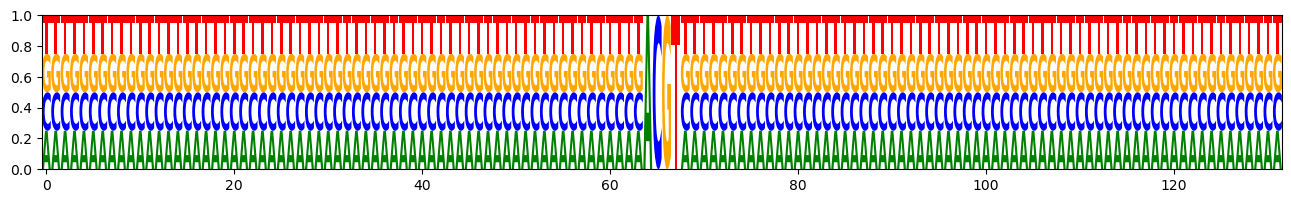

In [99]:
t.show()

In [118]:
from seqprop.seqprop import FastSeqProp

import torch.nn as nn

sp = FastSeqProp(template, n_samples=1)
sp._score_fn = _score
sp

FastSeqProp(
  (sampler): OneHotCategoricalSampler()
  (norm): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
)

In [119]:
res = sp.design(steps=500)
res

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 881.78it/s]


(array([[3.02448533e-02, 1.42999440e-01, 7.99924076e-01, 2.68316492e-02],
        [7.80414194e-02, 7.08371878e-01, 1.45617068e-01, 6.79696575e-02],
        [2.21839286e-02, 8.73042122e-02, 8.71275902e-01, 1.92359909e-02],
        [4.13714796e-02, 8.27808082e-01, 9.65293124e-02, 3.42911296e-02],
        [3.80034633e-02, 1.19012445e-01, 8.09237540e-01, 3.37465256e-02],
        [3.02792788e-02, 8.66996944e-01, 7.81836361e-02, 2.45402083e-02],
        [7.28401095e-02, 1.68746561e-01, 6.91671252e-01, 6.67421073e-02],
        [7.31331408e-02, 7.21546292e-01, 1.40410721e-01, 6.49097413e-02],
        [3.48074995e-02, 1.13253266e-01, 8.21153343e-01, 3.07858363e-02],
        [3.04484442e-02, 8.66384804e-01, 7.84798414e-02, 2.46869475e-02],
        [1.25032838e-03, 1.50527284e-02, 9.82731998e-01, 9.65019513e-04],
        [1.24934968e-03, 9.89681423e-01, 8.24681763e-03, 8.22353933e-04],
        [5.64452166e-05, 2.17036111e-03, 9.97734666e-01, 3.85902495e-05],
        [4.38029529e-04, 9.95396435e-0

In [147]:
from seqprop.templating import sequence_to_multihot

class DoubleGpCPenalty(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1d = nn.Conv1d(4, 1, 4, bias=True)
        self.conv1d.weight = nn.Parameter(sequence_to_multihot('GCGC').float().unsqueeze(0).transpose(1, 2))
        self.conv1d.bias = nn.Parameter(torch.tensor([-3.0]))

    def forward(self, inputs):
        return F.relu(self.conv1d(inputs.transpose(1, 2))).sum(dim=-1).mean()
    
p = DoubleGpCPenalty()

p(sequence_to_multihot('AAGCGCAAGCGGCGC').unsqueeze(0).float())

tensor(2., grad_fn=<MeanBackward0>)

In [ ]:
# Create a Conv1d layer with a single kernel
conv1d_layer = nn.Conv1d(in_channels=4, out_channels=1, kernel_size=3, bias=False)

# Define user-defined weights
user_defined_weights = torch.tensor([[[0.1, 0.2, 0.3],
                                      [0.4, 0.5, 0.6],
                                      [0.7, 0.8, 0.9],
                                      [1.0, 1.1, 1.2]]])

# Assign the user-defined weights to the Conv1d layer
conv1d_layer.weight = nn.Parameter(user_defined_weights)

conv1d_layer

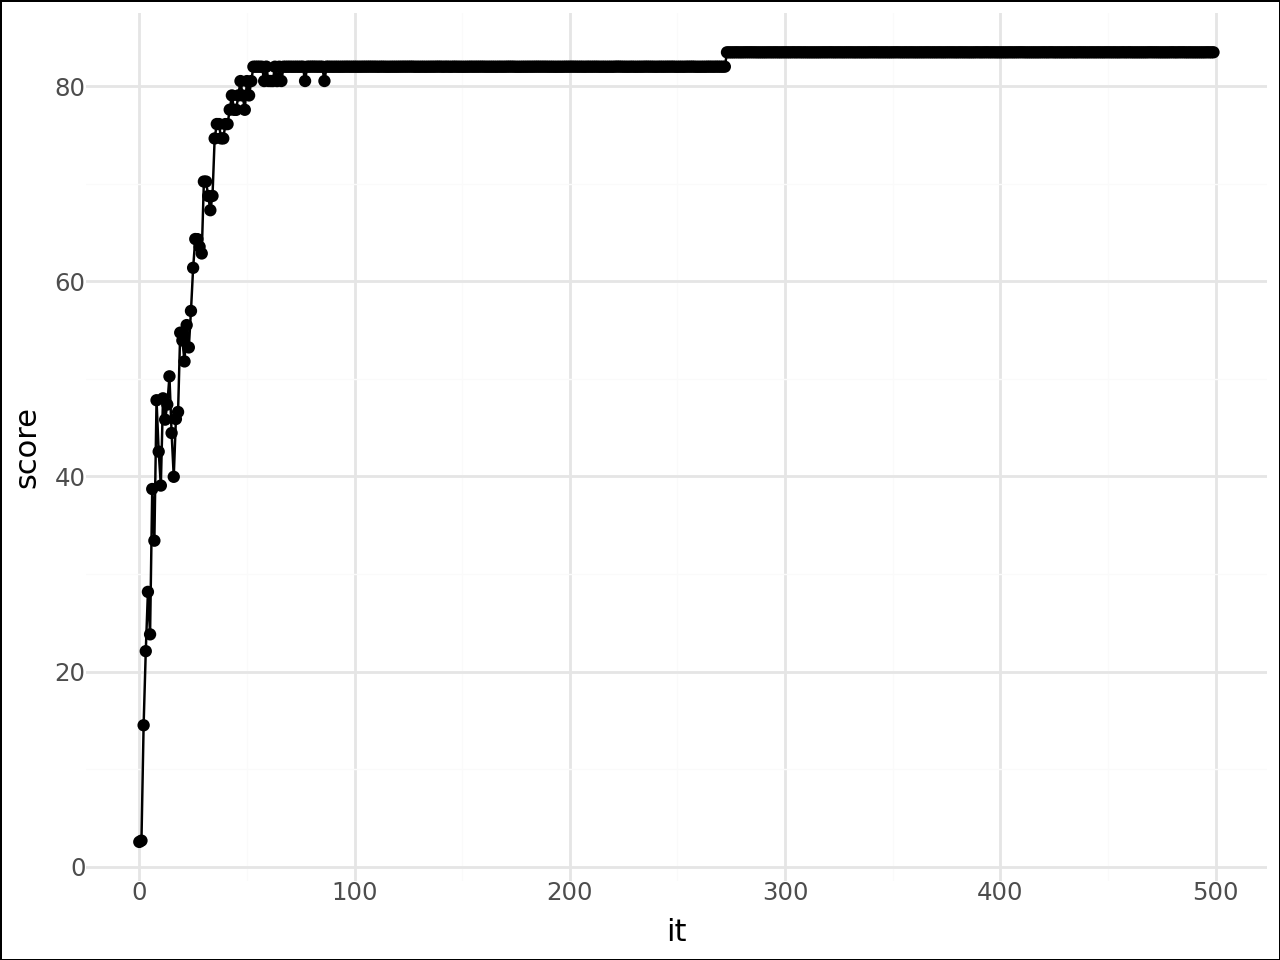

In [120]:
import pandas as pd
import plotnine as p9

g = (
    p9.ggplot(pd.DataFrame({'score': res[-1], 'it': list(range(len(res[-1])))}), p9.aes(x="it", y="score"))
    + p9.geom_point() + p9.geom_line()
    + p9.theme_minimal()
    + p9.theme(plot_background=p9.element_rect(fill="white"))
)
g

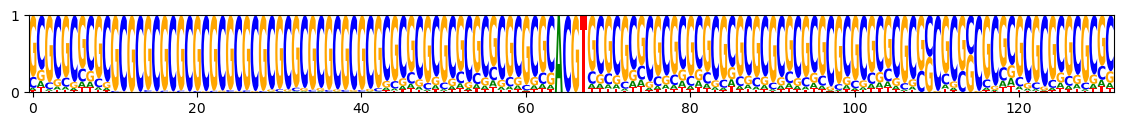

In [121]:
from seqprop.plot import pwm_logo

pwm_logo(res[0], figsize=(14, 1))

In [ ]:
crp_df = -logomaker.get_example_matrix('crp_energy_matrix',
                                        print_description=False)
crp_df

In [ ]:
from seqprop.templating import extended_nt_to_multi_hot

t = extended_nt_to_multi_hot('NAUGN')
t

In [ ]:
l = torch.rand(*t.shape)
l

In [ ]:
l_m = l - (1 - t) * torch.tensor(1e10)
l_m

In [ ]:
torch.tensor(1e10)

In [ ]:
(1 - t) * torch.inf

In [ ]:
from seqprop.ste import OneHotCategoricalSampler

sampler = OneHotCategoricalSampler(n=1)
sampler(l_m)


In [ ]:
from seqprop.plot import pwm_logo
import matplotlib.pyplot as plt

# crate matplotlib axis
fig, ax = plt.subplots(figsize=(16, 2))

# load crp energy matrix
crp_df = -logomaker.get_example_matrix('crp_energy_matrix',
                                        print_description=False)

# create Logo object
crp_logo = logomaker.Logo(crp_df,
                          shade_below=.5,
                          fade_below=.5,
                          ax=ax)

In [ ]:
import logomaker

# load crp energy matrix
crp_df = -logomaker.get_example_matrix('crp_energy_matrix',
                                        print_description=False)

# create Logo object
crp_logo = logomaker.Logo(crp_df,
                          shade_below=.5,
                          fade_below=.5)
crp_logo

# # style using Logo methods
# crp_logo.style_spines(visible=False)
# crp_logo.style_spines(spines=['left', 'bottom'], visible=True)
# crp_logo.style_xticks(rotation=90, fmt='%d', anchor=0)

# # style using Axes methods
# crp_logo.ax.set_ylabel("$-\Delta \Delta G$ (kcal/mol)", labelpad=-1)
# crp_logo.ax.xaxis.set_ticks_position('none')
# crp_logo.ax.xaxis.set_tick_params(pad=-1)

In [ ]:
import numpy as np

# load saliency matrix
nn_df = logomaker.get_example_matrix('nn_saliency_matrix',
                                     print_description=False)

# create Logo object
nn_logo = logomaker.Logo(nn_df)

# style using Logo methods
nn_logo.style_spines(visible=False)
nn_logo.style_spines(spines=['left'], visible=True, bounds=[0, .75])

# style using Axes methods
nn_logo.ax.set_xlim([20, 115])
nn_logo.ax.set_xticks([])
nn_logo.ax.set_ylim([-.6, .75])
nn_logo.ax.set_yticks([0, .75])
nn_logo.ax.set_yticklabels(['0', '0.75'])
nn_logo.ax.set_ylabel('                 saliency', labelpad=-1)

# set parameters for drawing gene
exon_start = 55-.5
exon_stop = 90+.5
y = -.2
xs = np.arange(-3, len(nn_df),10)
ys = y*np.ones(len(xs))

# draw gene
nn_logo.ax.axhline(y, color='k', linewidth=1)
nn_logo.ax.plot(xs, ys, marker='4', linewidth=0, markersize=7, color='k')
nn_logo.ax.plot([exon_start, exon_stop],
                [y, y], color='k', linewidth=10, solid_capstyle='butt')

# annotate gene
nn_logo.ax.plot(exon_start, 1.8*y, '^k', markersize=15)
nn_logo.ax.text(20,2*y,'$U2SURP$',fontsize=12)
nn_logo.ax.text(exon_start, 2.5*y,'chr3:142,740,192', verticalalignment='top', horizontalalignment='center')

In [39]:
import matplotlib.pyplot as plt

crp_logo.draw()

In [ ]:
crp_logo.__dict__

In [ ]:
pd.DataFrame(res[0], columns=list('ACGT'))

In [ ]:
import logomaker
logomaker.demo('fig1b')

In [ ]:
import logomaker

# load ss probability matrix
ss_df = logomaker.get_example_matrix('ss_probability_matrix',
                                     print_description=False)

# create Logo object
ss_logo = logomaker.Logo(ss_df,
                         width=.8,
                         vpad=.05,
                         fade_probabilities=True,
                         stack_order='small_on_top',
                         color_scheme='dodgerblue',
                         font_name='Rosewood Std')

# style using Logo methods
ss_logo.style_spines(spines=['left', 'right'], visible=False)

# style using Axes methods
ss_logo.ax.set_xticks(range(len(ss_df)))
ss_logo.ax.set_xticklabels('%+d'%x for x in [-3, -2, -1, 1, 2, 3, 4, 5, 6])
ss_logo.ax.set_yticks([0, .5, 1])
ss_logo.ax.axvline(2.5, color='k', linewidth=1, linestyle=':')
ss_logo.ax.set_ylabel('probability')

In [ ]:
sp.norm.weight

In [ ]:
sampler(torch.tensor(res[0]))[0].shape

In [ ]:
sampler(torch.tensor(res[0]))[0]

In [ ]:
sampler(torch.tensor(res[0]))[0].argmax(dim=1)

In [ ]:
count_GpC(sampler(torch.tensor(res[0]))[0].argmax(dim=1))